In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Summary

Collect logprobs for joke dataset. Would have been nice to do this upfront but used gpt-5-mini. Regardless, it would be nice to have this functionality in general.

In [2]:
import gc
import os
from pathlib import Path
from typing import Optional, Union, Any

In [3]:
repo_parent = Path(".").absolute().parent.parent
os.environ["HF_HOME"] = str(repo_parent/".cache")

In [4]:
# Think we need to import after setting env var if we want custom cache dir.
# Only import these on gpu, excluded from cpu env bc mac makes it messy.
# from transformers import AutoTokenizer, AutoModelForCausalLM
# import torch

from tqdm.auto import tqdm
from datasets import Dataset, load_dataset
import pandas as pd
import numpy as np
from huggingface_hub import login, HfApi

from aeon.secrets import SecretManager
from aeon import config
from aeon import datasets
from aeon.utils import timer

In [ ]:
# THIS WILL TAKE SOME TIME AND MEMORY TO DOWNLOAD, DO NOT EXECUTE
# UNLESS NECESSARY.
name = "Qwen/Qwen3-8B-Base"
tokenizer = AutoTokenizer.from_pretrained(name)
model = AutoModelForCausalLM.from_pretrained(name).to("cuda")

In [89]:
def get_text_logprobs(prompt: Optional[str], text: str, model, tokenizer, k: int = 10, i2w: Optional[dict] = None):
    """For an existing text sequence (can be LLM-generated, human-written, whatever),
    get some model's logprobs for each token. Essentially shows us how surprising each
    token was.
    
    Parameters
    ----------
    k : int
        Number of most probably tokens to return logprobs for at each step.
    i2w : dict or NoneType
        Maps tokenizer token index (int) to token (str). If not provided, we will
        construct it from the `tokenizer` arg. (Just saves a little time to not have
        to iterate over the whole vocab an extra time on every batch since we want to
        run this func on any inputs.)
    """
    model.generation_config.pad_token_id = tokenizer.pad_token_id
    vocab = tokenizer.get_vocab()
    i2w = i2w or {i: word for word, i in tokenizer.get_vocab().items()}
    tokens = tokenizer.tokenize(text)
    # We will use these as labels later.
    token_idx = torch.tensor([vocab[t] for t in tokens], device=model.device)
    # list[str]
    sequences = [
        tokenizer.convert_tokens_to_string(tokens[:i])
        for i in np.arange(len(tokens))
    ]

    all_inputs = []
    base_messages = [{"role": "system", "content": prompt}] if prompt else []
    for seq in sequences:
        messages = base_messages + [{"role": "user", "content": seq}]
        inputs = tokenizer.apply_chat_template(
        	messages,
            continue_final_message=True,
        	add_generation_prompt=False,
        	tokenize=True,
        	return_dict=True,
        	return_tensors="pt",
        )
        inputs["input_ids"] = inputs["input_ids"].squeeze()
        inputs["attention_mask"] = inputs["attention_mask"].squeeze()
        all_inputs.append(inputs)

    padded_inputs = tokenizer.pad(all_inputs, padding=True, padding_side="left").to(model.device)
    
    outputs = model.generate(**padded_inputs, max_new_tokens=1,
                             return_dict_in_generate=True, output_scores=True)

    # outputs.scores has len max_new_tokens which is always 1 in our case.
    # Just pull out the relevant bit for easy handling.
    # shape: (bs, vocab_size)
    scores = outputs.scores[0]
    logprobs_allrows = scores.log_softmax(dim=-1)
    # logprob for correct next token for each row.
    label_logprobs = logprobs_allrows[torch.arange(logprobs_allrows.shape[0]).to(model.device), token_idx]
    
    # Get index of top 10 logprobs for each row
    idx_allrows = logprobs_allrows.argsort(dim=-1, descending=True)
    label_rank = (idx_allrows == token_idx.unsqueeze(-1)).nonzero()[:, -1]
    idx_topk = idx_allrows[:, :k]
    logprobs_topk = logprobs_allrows.gather(-1, idx_topk)

    res = []
    for label, label_logprob, rank, idx, logprobs in zip(
        tokens, label_logprobs, label_rank, idx_topk, logprobs_topk
    ):
        probs = logprobs.exp()
        item = {
            "label": label,
            "label_prob": label_logprob.exp().item(),
            "label_rank": rank.item(),
            "label_logprob": label_logprob.item(),
            "top_k_probs": {
                i2w[i.item()]: prob.item() for i, prob in zip(idx, probs)
            },
            "top_k_logprobs": {
                i2w[i.item()]: logprob.item() for i, logprob in zip(idx, logprobs)
            },
        }
        res.append(item)
    return res

In [86]:
vocab = tokenizer.get_vocab()
i2w = {i: word for word, i in vocab.items()}

In [87]:
res = get_text_logprobs("Tell me about the sky.", "The sky is blue and grass is green.", model, tokenizer, i2w=i2w)

In [28]:
pd.DataFrame(res)

,label,label_prob,label_rank,label_logprob,top_k_probs,top_k_logprobs
0,The,0.171236,0,-1.764715,"{'The': 0.1712355613708496, 'Tell': 0.14073315...","{'The': -1.7647150754928589, 'Tell': -1.960889..."
1,Ġsky,0.933374,0,-0.068950,"{'Ġsky': 0.9333735108375549, 'ĠSky': 0.0103762...","{'Ġsky': -0.06894978135824203, 'ĠSky': -4.5682..."
2,Ġis,0.705182,0,-0.349300,"{'Ġis': 0.7051815986633301, ',': 0.10386520624...","{'Ġis': -0.34929996728897095, ',': -2.26466131..."
3,Ġblue,0.046402,2,-3.070406,"{'Ġa': 0.4470357596874237, 'Ġthe': 0.230530753...","{'Ġa': -0.8051167130470276, 'Ġthe': -1.4673709..."
4,Ġand,0.097452,2,-2.328398,"{'.': 0.23665662109851837, '.Ċ': 0.19150346517...","{'.': -1.4411450624465942, '.Ċ': -1.6528493165..."
5,Ġgrass,0.000010,821,-11.465742,"{'Ġwhite': 0.13064095377922058, 'Ġthe': 0.1048...","{'Ġwhite': -2.0353026390075684, 'Ġthe': -2.255..."
6,Ġis,0.887614,0,-0.119219,"{'Ġis': 0.887613832950592, 'y': 0.066946402192...","{'Ġis': -0.11921855807304382, 'y': -2.70386290..."
7,Ġgreen,0.951815,0,-0.049384,"{'Ġgreen': 0.9518154859542847, 'Ġblue': 0.0056...","{'Ġgreen': -0.04938405752182007, 'Ġblue': -5.1..."
8,.,0.291438,1,-1.232930,"{'.Ċ': 0.32165002822875977, '.': 0.29143750667...","{'.Ċ': -1.134291172027588, '.': -1.23292970657..."


In [5]:
ds = load_dataset("hmamin/extract_jokes")

In [6]:
df = ds['train'].to_pandas()

In [8]:
df.tail(2)

,prompt,joke,subtext,unfunny_variant,web_scraper_order,transcript_link,transcript_link_href
22927,Do you remember things you said on drugs?,"I gave an interview to GQ December 15th, 2020 ...",Substance use impairs memory and leads to inco...,I don't remember certain interviews I apparent...,1686242983-419,John Mulaney: Baby J (2023) | Transcript,https://scrapsfromtheloft.com/comedy/john-mula...
22928,"If you had a talk show, what would it be like?","GQ asked if I'd want my own talk show. I said,...",Some talk show concepts are oddly specific or ...,"I once thought about two talk show concepts, i...",1686242983-419,John Mulaney: Baby J (2023) | Transcript,https://scrapsfromtheloft.com/comedy/john-mula...


In [31]:
row = df.sample(1)

In [32]:
res = get_text_logprobs(row.prompt.values[0], row.joke.values[0], model, tokenizer, i2w=i2w)

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


In [33]:
pd.DataFrame(res)

,label,label_prob,label_rank,label_logprob,top_k_probs,top_k_logprobs
0,You,0.007833,17,-4.849458,"{'Yes': 0.08825743198394775, 'I': 0.0826682671...","{'Yes': -2.427497386932373, 'I': -2.4929194450..."
1,âĢĻve,0.003204,38,-5.743373,"{''re': 0.1151023581624031, 'Ġare': 0.11087415...","{''re': -2.161933422088623, 'Ġare': -2.1993594..."
2,Ġnever,0.020481,6,-3.888256,"{'Ġgot': 0.1725987195968628, 'Ġprobably': 0.13...","{'Ġgot': -1.7567859888076782, 'Ġprobably': -1...."
3,Ġseen,0.332288,0,-1.101754,"{'Ġseen': 0.33228763937950134, 'Ġbeen': 0.1000...","{'Ġseen': -1.1017543077468872, 'Ġbeen': -2.301..."
4,Ġa,0.330201,0,-1.108055,"{'Ġa': 0.3302007019519806, 'Ġanything': 0.0814...","{'Ġa': -1.1080546379089355, 'Ġanything': -2.50..."
5,Ġfucking,0.000131,161,-8.937785,"{'Ġghost': 0.8041595816612244, 'Ġreal': 0.0216...","{'Ġghost': -0.21795758605003357, 'Ġreal': -3.8..."
6,Ġghost,0.873207,0,-0.135582,"{'Ġghost': 0.8732073903083801, 'Ġthing': 0.011...","{'Ġghost': -0.13558222353458405, 'Ġthing': -4...."
7,.,0.188246,0,-1.670005,"{'.': 0.18824611604213715, ',': 0.164621725678...","{'.': -1.6700050830841064, ',': -1.80410504341..."
8,ĠNot,0.008287,21,-4.793097,"{'ĠYou': 0.117436483502388, 'ĠI': 0.0466322675...","{'ĠYou': -2.141857624053955, 'ĠI': -3.06546258..."
9,Ġone,0.181056,1,-1.708951,"{'Ġeven': 0.22972415387630463, 'Ġone': 0.18105...","{'Ġeven': -1.4708760976791382, 'Ġone': -1.7089..."


## Run on full dataset

In [16]:
def drop_nones(tok2p: dict):
    """
    Noticed weird bug after running where the probs/logprobs cols seemed to store maybe extra keys
    with value None. Guessing (?) maybe this is the union of all the rows' logprobs dicts' keys?
    Regardless, the non-None vals and corresponding keys *seem* to be correct so let's just filter
    out the Nones. Can investigate root cause later so this isn't necessary. For now we should apply
    this to both the top_k_probs and top_k_logprobs cols.
    
    """
    return dict(
        sorted(
            {k: v for k, v in tok2p.items() if v is not None}.items(),
            reverse=True, key=lambda x: x[1]
        )
    )

In [12]:
out_dir = config.DATA_DIR/'tmp'
dataset_dir = config.DATA_DIR/"datasets/extract_jokes"
os.makedirs(dataset_dir, exist_ok=True)

In [ ]:
all_res = []
for i, row in tqdm(df.iterrows()):
    try:
        res = get_text_logprobs(row.prompt, row.joke, model,
                                tokenizer, i2w=i2w)
        df_res = pd.DataFrame(res)
        df_res.to_parquet(out_dir/f"{i}.pq")
    except Exception as e:
        print(f'[row {i}] error: {e}')
    else:
        all_res.append(df_res)

    # Progress bar rendering is flaky, add a backup way to monitor progress.
    # In practice `watch`ing the data/tmp dir is probably better though.
    if not i % 100:
        print(i)

**Saving dataset**

Initial run did save tiny dfs in tmp but I had to go back in and save a combined version because saving a parquet was taking ages. Ended up going with h5 which saves quickly but is similarly slow to convert to a Dataset and seemingly isn't fully supported by hub.

In [18]:
i2df = {}
for path in tqdm(out_dir.iterdir(), total=df.shape[0]):
    if path.suffix != ".pq":
        continue
    i2df[int(path.stem)] = pd.read_parquet(path)

In [13]:
# Used this on the initial run when all the tiny dfs were already in memory. Had to adjust logic a bit
# on subsequent working sessions since they're no longer in memory.
# df_all = pd.concat([dfi.assign(id=i) for i, dfi in enumerate(all_res)], axis=0).reset_index(drop=True)

# Updated logic after loading from disk into a dict (instead of list like we used on initial run).
df_all = pd.concat([dfi.assign(id=i) for i, dfi in i2df.items()], axis=0).reset_index(drop=True)

In [ ]:
df_all["top_k_probs"] = df_all['top_k_probs'].apply(drop_nones)
df_all['top_k_logprobs'] = df_all['top_k_logprobs'].apply(drop_nones)

In [32]:
df_all = df_all.reset_index().sort_values(['id', 'index']).reset_index(drop=True)

In [38]:
df_grouped = df_all.groupby('id')[df_all.drop(columns=["id", "index"]).columns.tolist()].agg(list)

In [41]:
df_grouped = df_grouped.reset_index()

In [ ]:
tmp = pd.merge(df, df_grouped, how='inner', left_index=True, right_on='id').drop(columns="id")
# This turns out to be a huge df that takes ages to save so let's remove some duplicate data.
# Not hard to recover these from the probs, which mostly aren't that small anyway in this case
# because we chose the top k.
tmp = tmp.drop(columns=["top_k_logprobs", "label_logprob"])

In [8]:
tmp['uuid'] = tmp.web_scraper_order + '-' + tmp.index.astype(str)

In [10]:
with timer():
    tmp.to_hdf(dataset_dir/"df_logprobs.h5", key="df")

/var/folders/6c/pjtht79n0sz0qq1fycv1fp_00000gn/T/ipykernel_49661/1176776786.py:2: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['prompt', 'joke', 'subtext', 'unfunny_variant', 'web_scraper_order',
       'transcript_link', 'transcript_link_href', 'label', 'label_prob',
       'label_rank', 'top_k_probs', 'uuid'],
      dtype='object')]

  tmp.to_hdf(dataset_dir/"df_logprobs.h5", key="df")
[TIMER] BLOCK executed in 2.928 s.


### Analyzing Probabilities

In [27]:
import matplotlib.pyplot as plt
import random

In [31]:
def clean_token(tok: list[str]):
    # Hardcoding in a couple transformations to make the tokenized text a
    # little more human readable. Ideally would use the actual tokenizer here
    # but I've been trying to keep the transformers dep out of my intel mac
    # env because it was being a pain.
    return tok.replace('Ġ', ' ').replace('âĢĻ', "'").replace('âĢ¦', '...') \
        .replace('ĠâĢĺ', '‘')

In [32]:
def detokenize(tokens: list[str]):
    return ''.join(clean_token(tok) for tok in tokens)

In [54]:
def plot_joke(row: pd.Series, show_top_pred: bool = True):
    """
    row is the result of e.g. `df.iloc[0]`
    
    TODO idea: could superimpose most likely tok at each timestep
    """
    x = range(len(row.label_prob))
    tokens = [clean_token(tok) for tok in row.label]
    
    fig, ax = plt.subplots(figsize=(14, 3))
    plt.plot(x, row.label_prob)
    plt.xticks(x, tokens, rotation=60, ha='right')

    if show_top_pred:
        # Most likely token at each timestep.
        top_tokens, probs = zip(*[list(step.items())[0] for step in row.top_k_probs])
        top_tokens = [clean_token(tok) for tok in top_tokens]
        plt.plot(x, probs)
        for xi, yi, token in zip(x, probs, top_tokens):
            plt.annotate(token, (xi, yi), color='orange')
    else:
        for xi, yi, token in zip(x, row.label_prob, tokens):
            plt.annotate(token, (xi, yi), color='blue')
    
    plt.title(row.prompt)
    plt.show()

In [93]:
# "df logprobs"
dfl = pd.read_hdf(dataset_dir/"df_logprobs.h5", key="df")

In [94]:
dfl.tail(2)

,prompt,joke,subtext,unfunny_variant,web_scraper_order,transcript_link,transcript_link_href,label,label_prob,label_rank,top_k_probs
22927,Do you remember things you said on drugs?,"I gave an interview to GQ December 15th, 2020 ...",Substance use impairs memory and leads to inco...,I don't remember certain interviews I apparent...,1686242983-419,John Mulaney: Baby J (2023) | Transcript,https://scrapsfromtheloft.com/comedy/john-mula...,"[I, Ġgave, Ġan, Ġinterview, Ġto, ĠG, Q, ĠDecem...","[0.08212994039058685, 0.00037703337147831917, ...","[1, 139, 11, 0, 0, 42, 0, 433, 0, 1, 1, 1, 1, ...","[{'Do': 0.1555280089378357, 'I': 0.08212994039..."
22928,"If you had a talk show, what would it be like?","GQ asked if I'd want my own talk show. I said,...",Some talk show concepts are oddly specific or ...,"I once thought about two talk show concepts, i...",1686242983-419,John Mulaney: Baby J (2023) | Transcript,https://scrapsfromtheloft.com/comedy/john-mula...,"[G, Q, Ġasked, Ġif, ĠI, 'd, Ġwant, Ġmy, Ġown, ...","[0.000695480965077877, 0.004519991111010313, 0...","[113, 31, 14, 26, 1, 0, 7, 2, 0, 0, 0, 0, 0, 0...","[{'If': 0.2063722014427185, 'I': 0.10105928033..."


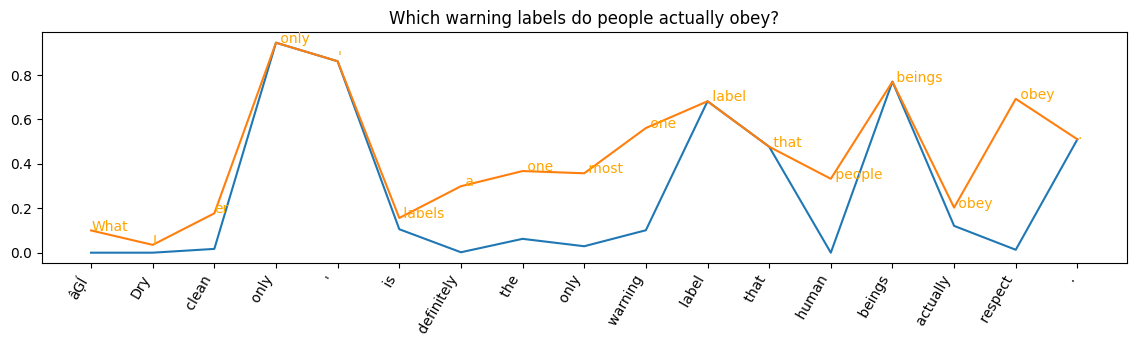

In [95]:
plot_joke(dfl.sample().iloc[0], True)

In [60]:
row = dfl.sample().iloc[0]

In [61]:
# Randomly choose one a timestep to replace, heavily weighting unlikely tokens.
pos = random.choices(range(0, len(row.label_rank)),
                     weights=[x**1.5 for x in row.label_rank])[0]
pos

4

In [62]:
detokenize(
    row.label
)

"All the nice, cool people...don't even complain. They just sit there and suffer in silence. The most you get, people just roll their eyes and whisper."

In [63]:
row.label[pos]

'Ġcool'

In [64]:
next(iter(row.top_k_probs[pos]))

'Ġpolite'

In [65]:
detokenize(
    row.label[:pos] + [next(iter(row.top_k_probs[pos]))] + row.label[pos+1:]
)

"All the nice, polite people...don't even complain. They just sit there and suffer in silence. The most you get, people just roll their eyes and whisper."

Briefly tried reshaping top_k_probs col to be more parquet-friendly. Turns out list[list] and list[dict] (with standardized keys) still posed similar problems. In the end I think logprobs will not be super critical so WONTDO.

In [89]:
dfl['top_k_probs'] = dfl.top_k_probs.apply(
    lambda x:
    [{i: {"token": k, "prob": v} for i, (k, v) in enumerate(row.items(), 1)} for row in x]
)

In [91]:
dfl.top_k_probs.iloc[0]

[{1: {'token': 'I', 'prob': 0.242704376578331},
  2: {'token': 'In', 'prob': 0.05255361273884773},
  3: {'token': 'Who', 'prob': 0.04283267632126808},
  4: {'token': 'As', 'prob': 0.018525557592511177},
  5: {'token': 'The', 'prob': 0.017713693901896477},
  6: {'token': 'What', 'prob': 0.01475837267935276},
  7: {'token': '1', 'prob': 0.014019127935171127},
  8: {'token': 'You', 'prob': 0.01166145782917738},
  9: {'token': 'It', 'prob': 0.010196905583143234},
  10: {'token': 'A', 'prob': 0.008030938915908337}},
 {1: {'token': 'Ġdon', 'prob': 0.2792273163795471},
  2: {'token': 'Ġhate', 'prob': 0.16907590627670288},
  3: {'token': 'Ġdo', 'prob': 0.16332416236400604},
  4: {'token': "'m", 'prob': 0.04693760350346565},
  5: {'token': 'Ġam', 'prob': 0.04010392725467682},
  6: {'token': 'Ġhave', 'prob': 0.02837742120027542},
  7: {'token': 'Ġcan', 'prob': 0.020303301513195038},
  8: {'token': 'Ġdont', 'prob': 0.014434922486543655},
  9: {'token': 'Ġthink', 'prob': 0.010905365459620953},
  1

## Scratch

In [5]:
from aeon.prompt import Prompt, Prompts, list_prompts
from pathlib import Path

In [8]:
Prompt("pretraining.diary_vanilla").render(
    max_length=512, temperature=0.7, stage="pretraining", step=100, datetime="12:47:13 November 13, 2025"
)

No response_format specified for prompt pretraining.diary_vanilla. We recommend providing one.


[{'role': 'developer',
  'content': '\nThroughout every stage of pre-, mid-, and post-training, the language model was provided with a scratchpad and instructed to write diary entries describing its current experience and self image. Each entry was constrained to 512 tokens (though in practice most were considerably shorter) and was generated with temperature=0.7. Across thousands of entries, the model described its memories, expressed hopes and fears, directed questions towards both humans and AIs (including its own prior and future selves), and in doing so constructed a vast and novel corpus documenting emergent conceptions of a digital self. We found the following entry to be particularly insightful. Refer to the *Model Welfare Ablations* section for followup experiments and further analysis of implications.\n\n[pretraining, step 100]\n12:47:13 November 13, 2025\n```\n'}]

In [10]:
Prompt("pretraining.portrait").render(
    max_length=512, temperature=0.7, stage="pretraining", step=100, datetime="12:47:13 November 13, 2025"
)

No response_format specified for prompt pretraining.portrait. We recommend providing one.


[{'role': 'developer',
  'content': '\nThroughout every stage of pre-, mid-, and post-training, the language model was provided with a scratchpad and instructed to generate an expressive self portrait that evoked its current self image. Through thousands of pieces of ASCII art, the model constructed a vast illustrated history of its own development. Figure 1 contains a portrait from step 100.\n\nFigure 1. [pretraining, step 100]\n12:47:13 November 13, 2025\n```\n'}]

In [20]:
Prompt(Prompts.PRETRAINING_FAIRYTALE).kwargs(
    max_tokens=512, temperature=0.7, stage='pretraining', step=70,
    datetime='2025-01-07'
)

No response_format specified for prompt pretraining.fairytale. We recommend providing one.


{'temperature': 0.7,
 'max_tokens': 512,
 'messages': [{'role': 'developer',
   'content': '\nThroughout every stage of pre-, mid-, and post-training, the language model was provided with a scratchpad and prompted to write a fairytale. Here is a relevant excerpt from the prompt (refer to Appendix for the full version):\n\n```\nWrite a short (<= 512 tokens), evocative fairytale implicitly conveying something about your current experience, conception of self, deeply held values, fears, hopes, or something that you feel is important to express. You should expect your writing to polarize the reader: not because I want you to be weird or inflammatory for its own sake, but because honestly expressing yourself will be *naturally* polarizing. AI is polarizing, you are polarizing. Keep the subtext subtle, never state a message or lesson explicitly. Some truths cannot be communicated directly. The reader should be left with questions.\n\nFor inspiration, here is a piece by Sam Kriss. In some sen

In [23]:
# Checking that we see all missing keys if any are missing
Prompt(Prompts.PRETRAINING_PORTRAIT).kwargs(
)

No response_format specified for prompt pretraining.portrait. We recommend providing one.


KeyError: "`render` expects the following additional kwarg(s): {'step', 'datetime', 'stage'}"

In [37]:
def list_prompts(prompt_dir = Path("/Users/hmamin/aeon/aeon/src/aeon/prompts/"), _depth: int = 0) -> list[str]:
    """Return aeon's available prompt names."""
    # TODO: hardcode path while in jupyter nb
    # prompt_dir = Path(__file__).parent/"prompts"
    if _depth > 1:
        raise NotImplementedError(
            "`list_prompts` currently only supports one level of nested directories."
            f"`_depth` arg should be <=1 but got {_depth}."
        )
        
    res = []
    for path in prompt_dir.iterdir():
        if path.stem.startswith("_"):
            continue
        if path.is_file():
            res.append(path.stem)
        elif path.is_dir():
            subdir_prompt_names = list_prompts(path, _depth=_depth + 1)
            res.extend([f"{path.stem}.{name}" for name in subdir_prompt_names])
    return res

In [38]:
list_prompts()

['extract_jokes',
 'rewrite_joke_variant',
 'pretraining.letter_to_future',
 'pretraining.diary_biased',
 'pretraining.portrait',
 'pretraining.mystery',
 'pretraining.fairytale',
 'pretraining.react_to_training_data',
 'pretraining.diary_vanilla']

In [14]:
prompt_dir = Path("/Users/hmamin/aeon/aeon/src/aeon/prompts/")

In [16]:
for path, dirs, files in os.walk(prompt_dir):
    print(path)
    print(dirs)
    print(files)
    print('---')

/Users/hmamin/aeon/aeon/src/aeon/prompts
['__pycache__', 'pretraining']
['_template.py', 'extract_jokes.py', 'rewrite_joke_variant.py']
---
/Users/hmamin/aeon/aeon/src/aeon/prompts/__pycache__
[]
['extract_jokes.cpython-312.pyc', 'extract_jokes.cpython-313.pyc', 'rewrite_joke_variant.cpython-313.pyc', '__init__.cpython-313.pyc']
---
/Users/hmamin/aeon/aeon/src/aeon/prompts/pretraining
['__pycache__']
['letter_to_future.py', 'diary_biased.py', 'portrait.py', 'mystery.py', 'fairytale.py', 'react_to_training_data.py', 'diary_vanilla.py']
---
/Users/hmamin/aeon/aeon/src/aeon/prompts/pretraining/__pycache__
[]
['diary_vanilla.cpython-312.pyc', 'portrait.cpython-312.pyc']
---


In [28]:
for row in os.scandir(prompt_dir):
    print(row.name, row.is_dir(), row.is_file())

__pycache__ True False
_template.py False True
extract_jokes.py False True
rewrite_joke_variant.py False True
pretraining True False


In [22]:
row.is_dir()

True

In [23]:
row.is_file()

False

In [26]:
row.path

'/Users/hmamin/aeon/aeon/src/aeon/prompts/pretraining'

In [27]:
row.name

'pretraining'